# ZaloPay Data Analyst – Home Test
## Part II – Câu 1: Phân tích tổng hợp chân dung User ZaloPay
**Các chiều phân tích:** Demographic | Location | Channel & OrderFrom | Động lực thanh toán

---

## 0. Setup – Import thư viện & Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#F8F8F6',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.35,
    'grid.linestyle'  : '--',
    'font.family'     : 'DejaVu Sans',
})

# Màu sắc nhất quán
BLUE   = '#378ADD'
TEAL   = '#1D9E75'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'
GRAY   = '#888780'

In [7]:
# ── Load data ──────────────────────────────────────────────────────────────────
BASE = r"C:\Users\nhannt\Downloads\Assignment - DA"

fact     = pd.read_csv(r"C:\Users\nhannt\Downloads\Assignment - DA\fact.csv", parse_dates=['TransactionDate'])
merchant = pd.read_excel(r"C:\Users\nhannt\Downloads\Assignment - DA\dim_merchant.xlsx")
store    = pd.read_excel(r"C:\Users\nhannt\Downloads\Assignment - DA\dim_store.xlsx")

# Xử lý timezone & tạo cột phụ
fact['TransactionDate'] = fact['TransactionDate'].dt.tz_localize(None)
fact['month']           = fact['TransactionDate'].dt.to_period('M')
fact['year_month']      = fact['TransactionDate'].dt.strftime('%Y-%m')

# Join dimension tables
fact = fact.merge(merchant[['appid', 'merchantID', 'merchantName']],
                  left_on='appID', right_on='appid', how='left')
fact = fact.merge(store, on='storeID', how='left')

# Bảng user-level (1 dòng / user)
user_df = fact.drop_duplicates('userID')[['userID', 'Gender', 'is_kyc']].copy()

TOTAL_USERS = fact['userID'].nunique()
TOTAL_TXN   = len(fact)

print(f"✅ Load xong!")
print(f"Tổng users    : {TOTAL_USERS:,}")
print(f"Tổng giao dịch: {TOTAL_TXN:,}")
print(f"Thời gian     : {fact['TransactionDate'].min().date()} → {fact['TransactionDate'].max().date()}")
print(f"Cột fact      : {list(fact.columns)}")

✅ Load xong!
Tổng users    : 583,618
Tổng giao dịch: 1,048,575
Thời gian     : 2021-10-01 → 2023-01-09
Cột fact      : ['transID', 'userID', 'is_kyc', 'appID', 'Channel', 'OrderFrom', 'TransactionDate', 'SalesAmount', 'Gender', 'VoucherStatus', 'storeID', 'month', 'year_month', 'appid', 'merchantID', 'merchantName', 'Province']


---
## 1. Demographic – Họ là ai?

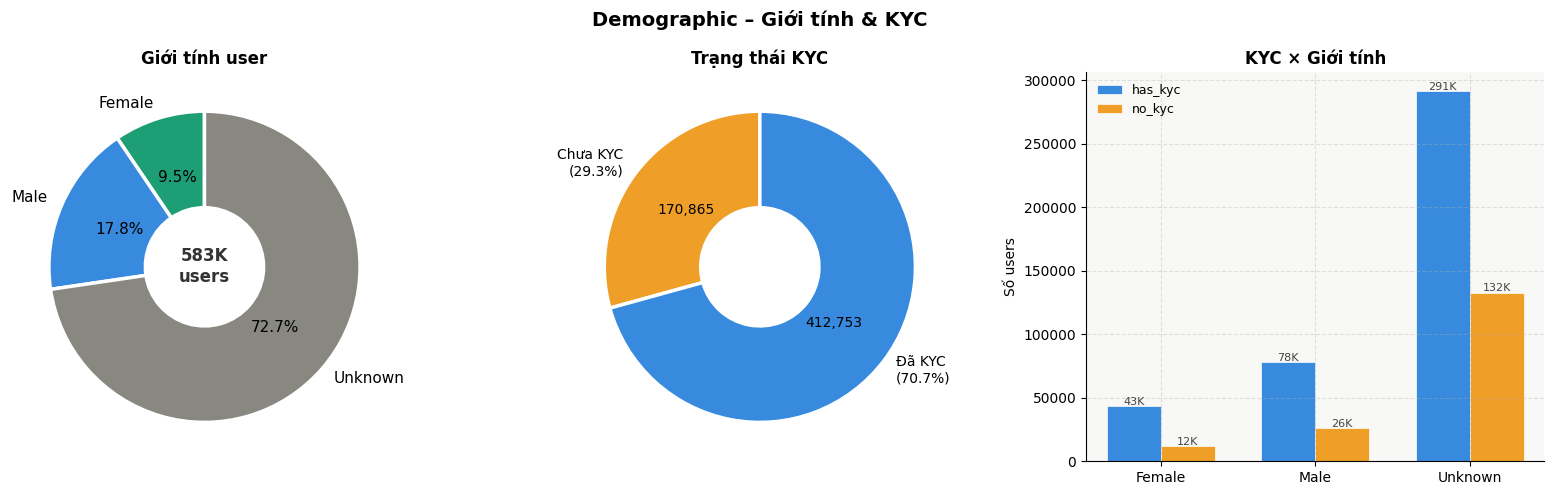

In [8]:
# Tính tỷ lệ giới tính và KYC
gender_u = user_df.groupby('Gender')['userID'].count()
kyc_u    = user_df.groupby('is_kyc')['userID'].count()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Demographic – Giới tính & KYC', fontsize=14, fontweight='bold')

# ── Giới tính – Donut ──────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
ax.pie(gender_u.values, labels=gender_u.index,
       autopct='%1.1f%%', colors=[TEAL, BLUE, GRAY],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2.5, 'width': 0.62},
       textprops={'fontsize': 11})
ax.set_title('Giới tính user', fontsize=12, fontweight='bold')
ax.text(0, 0, f'{TOTAL_USERS//1000}K\nusers',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#333')

# ── KYC – Donut ────────────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('white')
labels_kyc = [f'Chưa KYC\n({kyc_u["no_kyc"]/TOTAL_USERS*100:.1f}%)',
              f'Đã KYC\n({kyc_u["has_kyc"]/TOTAL_USERS*100:.1f}%)']
ax.pie([kyc_u['no_kyc'], kyc_u['has_kyc']], labels=labels_kyc,
       autopct=lambda p: f'{p*TOTAL_USERS/100:,.0f}',
       colors=[AMBER, BLUE], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2.5, 'width': 0.62},
       textprops={'fontsize': 10})
ax.set_title('Trạng thái KYC', fontsize=12, fontweight='bold')

# ── KYC × Giới tính – Grouped bar ─────────────────────────────────────────
ax = axes[2]
kg  = user_df.groupby(['is_kyc', 'Gender'])['userID'].count().unstack(fill_value=0)
x   = np.arange(len(kg.columns))
w   = 0.35
b1 = ax.bar(x - w/2, kg.loc['has_kyc'], w, label='has_kyc', color=BLUE,  edgecolor='white', lw=0.5)
b2 = ax.bar(x + w/2, kg.loc['no_kyc'],  w, label='no_kyc',  color=AMBER, edgecolor='white', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(kg.columns, fontsize=10)
ax.set_title('KYC × Giới tính', fontsize=12, fontweight='bold')
ax.set_ylabel('Số users')
ax.legend(fontsize=9, frameon=False)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1000,
                f'{h//1000}K', ha='center', fontsize=8, color='#444')

plt.tight_layout()
plt.show()

### 🔍 Insights – Demographic

- **71.2% user đã xác thực KYC (has_kyc)** → phần lớn user đã tin tưởng nền tảng đủ để cung cấp thông tin cá nhân. Đây là nền tảng tốt để cá nhân hoá trải nghiệm và tăng hạn mức giao dịch.
- **72.7% user không khai báo giới tính (Unknown)** → đây là điểm yếu lớn về data. Cần cải thiện quy trình onboarding để thu thập thông tin này, phục vụ phân tích hành vi theo giới.
- Trong nhóm đã khai báo: **Nam chiếm 65.3%, Nữ chiếm 34.7%** → ZaloPay đang nghiêng về user nam; cơ hội mở rộng sang tệp nữ còn lớn.
- Cả nam và nữ đều có tỷ lệ has_kyc cao hơn no_kyc → **user đã xác thực danh tính không phân biệt giới tính**.

---
## 2. Location – Họ ở đâu?

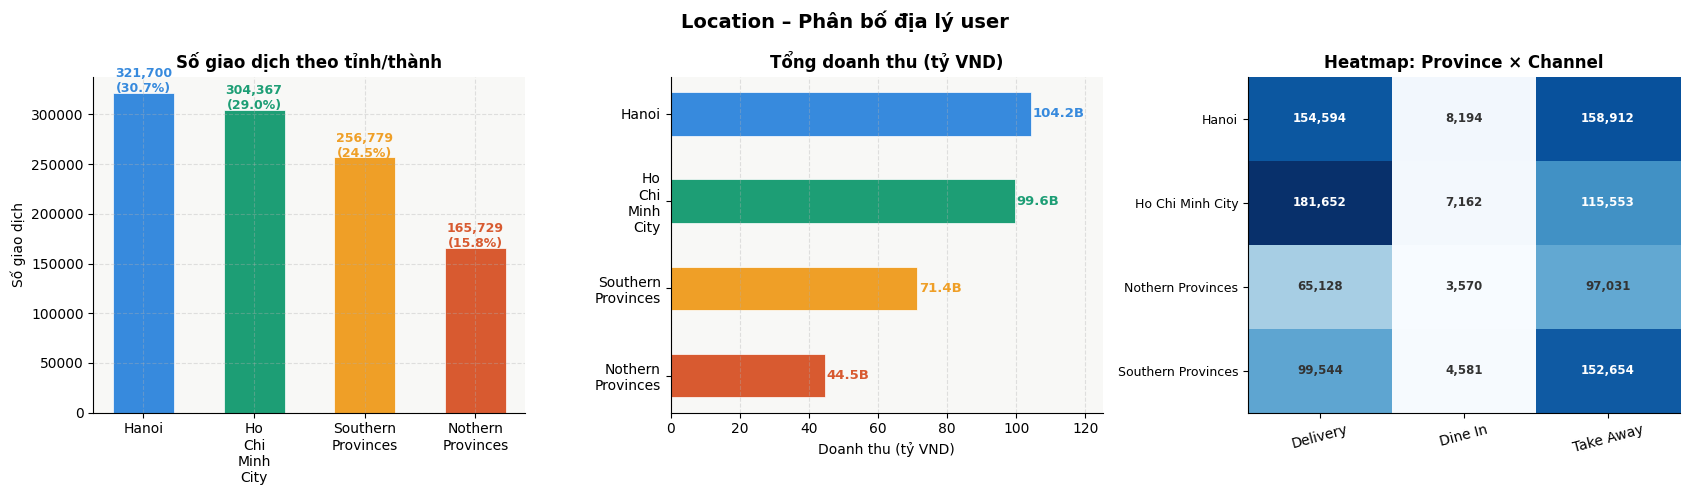

In [9]:
province_t  = fact.groupby('Province')['transID'].count().sort_values(ascending=False)
province_s  = fact.groupby('Province')['SalesAmount'].sum().sort_values(ascending=False)
prov_ch     = fact.groupby(['Province', 'Channel'])['transID'].count().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Location – Phân bố địa lý user', fontsize=14, fontweight='bold')

# ── Số giao dịch theo Province ─────────────────────────────────────────────
ax = axes[0]
colors_p = [BLUE, TEAL, AMBER, CORAL]
bars = ax.bar([l.replace(' ', '\n') for l in province_t.index],
              province_t.values, color=colors_p, width=0.55, edgecolor='white', lw=0.5)
ax.set_title('Số giao dịch theo tỉnh/thành', fontsize=12, fontweight='bold')
ax.set_ylabel('Số giao dịch')
for bar, col in zip(bars, colors_p):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 800,
            f'{h:,}\n({h/TOTAL_TXN*100:.1f}%)',
            ha='center', fontsize=9, fontweight='bold', color=col)

# ── Doanh thu theo Province ────────────────────────────────────────────────
ax = axes[1]
bars = ax.barh([l.replace(' ', '\n') for l in province_s.index[::-1]],
               province_s.values[::-1] / 1e9,
               color=colors_p[::-1], height=0.5, edgecolor='white', lw=0.5)
ax.set_title('Tổng doanh thu (tỷ VND)', fontsize=12, fontweight='bold')
ax.set_xlabel('Doanh thu (tỷ VND)')
for bar, col in zip(bars, colors_p[::-1]):
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}B', va='center', fontsize=9.5, fontweight='bold', color=col)
ax.set_xlim(0, province_s.max()/1e9 * 1.2)
ax.grid(axis='y', alpha=0)

# ── Heatmap Province × Channel ─────────────────────────────────────────────
ax = axes[2]
im = ax.imshow(prov_ch.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(prov_ch.columns)))
ax.set_xticklabels(prov_ch.columns, fontsize=10, rotation=15)
ax.set_yticks(range(len(prov_ch.index)))
ax.set_yticklabels(prov_ch.index, fontsize=9)
ax.set_title('Heatmap: Province × Channel', fontsize=12, fontweight='bold')
for i in range(len(prov_ch.index)):
    for j in range(len(prov_ch.columns)):
        v = prov_ch.values[i, j]
        ax.text(j, i, f'{v:,}', ha='center', va='center',
                color='white' if v > 100000 else '#333', fontsize=8.5, fontweight='bold')
ax.grid(False)

plt.tight_layout()
plt.show()

### 🔍 Insights – Location

- **Hanoi (30.7%) và HCM (29.0%) chiếm gần 60% tổng giao dịch** → 2 thị trường cốt lõi, cần ưu tiên giữ chân user tại đây.
- **Hanoi dẫn đầu cả về số giao dịch lẫn doanh thu (~104 tỷ VND)**, nhỉnh hơn HCM (~100 tỷ VND) trong kỳ quan sát.
- **Kênh thanh toán phân hoá theo vùng:**
  - HCM thiên về **Delivery** (60% giao dịch tại HCM) → thói quen giao hàng mạnh hơn.
  - Hanoi cân bằng hơn giữa Delivery và Take Away.
  - Southern & Northern Provinces nghiêng về **Take Away** → hành vi đến lấy trực tiếp phổ biến hơn ở tỉnh.

---
## 3. Channel & OrderFrom – Họ đặt hàng qua kênh nào?

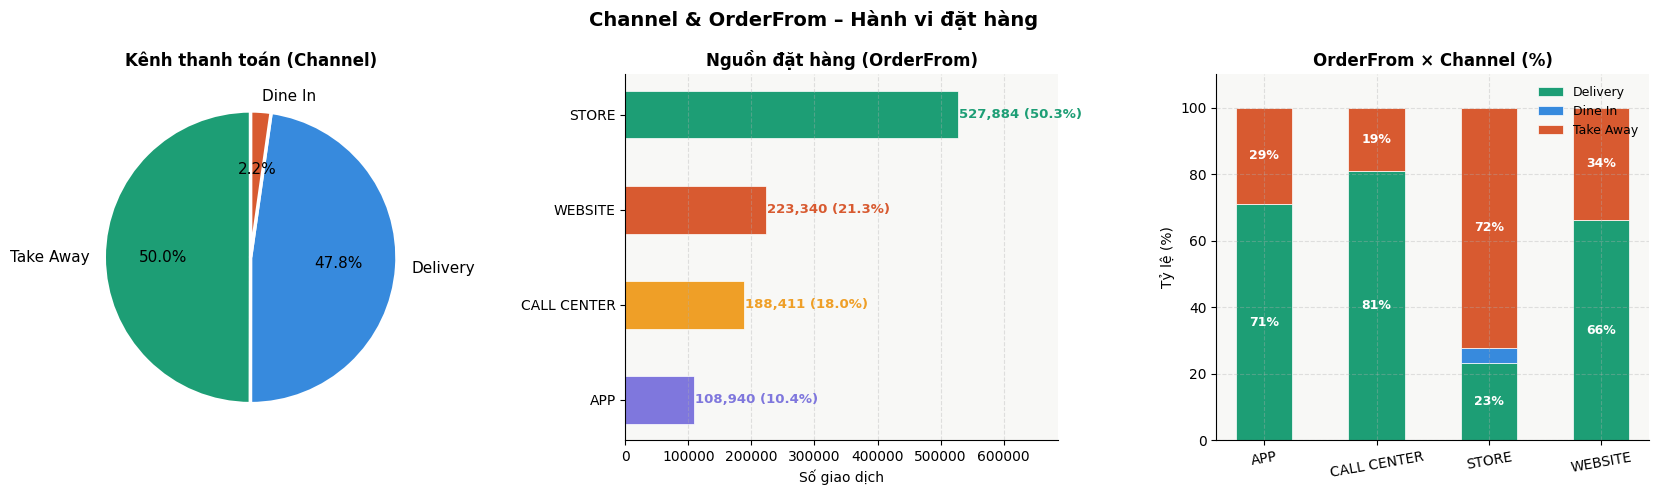

In [10]:
channel_t   = fact.groupby('Channel')['transID'].count().sort_values(ascending=False)
orderfrom_t = fact.groupby('OrderFrom')['transID'].count().sort_values(ascending=False)
of_ch       = fact.groupby(['OrderFrom', 'Channel'])['transID'].count().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Channel & OrderFrom – Hành vi đặt hàng', fontsize=14, fontweight='bold')

# ── Channel – Pie ──────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
ax.pie(channel_t.values, labels=channel_t.index, autopct='%1.1f%%',
       colors=[TEAL, BLUE, CORAL], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
       textprops={'fontsize': 11})
ax.set_title('Kênh thanh toán (Channel)', fontsize=12, fontweight='bold')

# ── OrderFrom – Horizontal bar ─────────────────────────────────────────────
ax = axes[1]
cols_of = [PURPLE, AMBER, CORAL, TEAL]
bars = ax.barh(orderfrom_t.index[::-1], orderfrom_t.values[::-1],
               color=cols_of, height=0.5, edgecolor='white', lw=0.5)
ax.set_title('Nguồn đặt hàng (OrderFrom)', fontsize=12, fontweight='bold')
ax.set_xlabel('Số giao dịch')
ax.set_xlim(0, orderfrom_t.max() * 1.3)
for bar, col in zip(bars, cols_of):
    w = bar.get_width()
    ax.text(w + 2000, bar.get_y() + bar.get_height()/2,
            f'{w:,} ({w/TOTAL_TXN*100:.1f}%)',
            va='center', color=col, fontsize=9.5, fontweight='bold')
ax.grid(axis='y', alpha=0)

# ── OrderFrom × Channel – Stacked bar ─────────────────────────────────────
ax = axes[2]
of_ch_pct = of_ch.div(of_ch.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(of_ch_pct))
colors_ch = [TEAL, BLUE, CORAL]
for col, color in zip(of_ch_pct.columns, colors_ch):
    bars = ax.bar(of_ch_pct.index, of_ch_pct[col], bottom=bottom,
                  label=col, color=color, edgecolor='white', lw=0.5, width=0.5)
    for bar, b, v in zip(bars, bottom, of_ch_pct[col]):
        if v > 5:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    f'{v:.0f}%', ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
    bottom += of_ch_pct[col].values
ax.set_title('OrderFrom × Channel (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Tỷ lệ (%)')
ax.set_xticklabels(of_ch_pct.index, rotation=10, fontsize=10)
ax.legend(fontsize=9, frameon=False, loc='upper right')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

### 🔍 Insights – Channel & OrderFrom

- **Take Away (50%) và Delivery (48%) gần như ngang nhau**
- **Dine In chỉ 2.2%** → thanh toán tại bàn chưa được khai thác, tiềm năng tích hợp QR tại bàn còn lớn.
- **STORE (walk-in) chiếm 50.3% OrderFrom** → rất nhiều user thanh toán trực tiếp tại điểm bán, không order từ xa → ZaloPay đang được dùng như **ví điện tử tại quầy** hơn là app đặt đồ.
- **APP chỉ 10.4%** → đây là điểm yếu lớn nhất. User chưa quen dùng app để đặt hàng → cần đẩy mạnh UX và incentive trên kênh app.
- **CALL CENTER (17.9%) vẫn còn cao** → một bộ phận user không tự đặt được qua digital, cần hỗ trợ thêm.
- Đặt qua **APP và WEBSITE không có Dine In** → kênh Dine In hoàn toàn đến từ walk-in tại STORE.

---
## 4. Động lực thanh toán – Voucher & Merchant preference

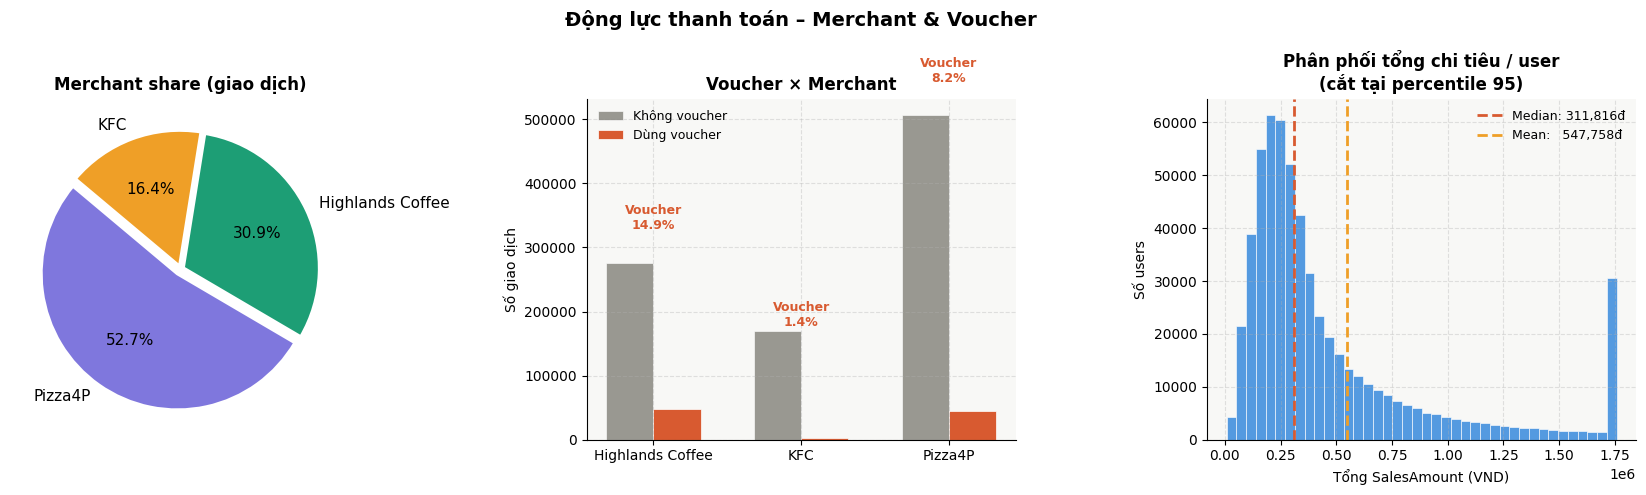

Voucher usage rate: 9.2%

Voucher rate theo merchant:
merchantName
Highlands Coffee    14.9
KFC                  1.4
Pizza4P              8.2

Chi tiêu / user:
count        583,618
mean         547,758
std          880,560
min            7,148
25%          201,287
50%          311,816
75%          567,463
90%        1,136,532
max      133,774,476
Name: SalesAmount, dtype: object

Số giao dịch / user:
count    583,618.0
mean           1.8
std            2.3
min            1.0
50%            1.0
75%            2.0
90%            3.0
max          238.0
Name: transID, dtype: object


In [11]:
merchant_t  = fact.groupby('merchantName')['transID'].count().sort_values(ascending=False)
voucher_t   = fact.groupby('VoucherStatus')['transID'].count()
vm          = fact.groupby(['merchantName', 'VoucherStatus'])['transID'].count().unstack(fill_value=0)
spend_user  = fact.groupby('userID')['SalesAmount'].sum()
txn_user    = fact.groupby('userID')['transID'].count()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Động lực thanh toán – Merchant & Voucher', fontsize=14, fontweight='bold')

# ── Merchant share – Pie ───────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
explode = (0.04, 0.02, 0.02)
ax.pie(merchant_t.values, labels=merchant_t.index, autopct='%1.1f%%',
       colors=[PURPLE, TEAL, AMBER], startangle=140, explode=explode,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
       textprops={'fontsize': 11})
ax.set_title('Merchant share (giao dịch)', fontsize=12, fontweight='bold')

# ── Voucher × Merchant – Grouped bar ──────────────────────────────────────
ax = axes[1]
x = np.arange(len(vm.index))
w = 0.32
ax.bar(x - w/2, vm['No'],  w, label='Không voucher', color=GRAY,  edgecolor='white', lw=0.5, alpha=0.85)
ax.bar(x + w/2, vm['Yes'], w, label='Dùng voucher',  color=CORAL, edgecolor='white', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(vm.index, fontsize=10)
ax.set_title('Voucher × Merchant', fontsize=12, fontweight='bold')
ax.set_ylabel('Số giao dịch')
ax.legend(fontsize=9, frameon=False)
v_rates = vm['Yes'] / (vm['No'] + vm['Yes']) * 100
for i, rate in enumerate(v_rates):
    total = vm.iloc[i].sum()
    ax.text(i, total + 5000, f'Voucher\n{rate:.1f}%',
            ha='center', color=CORAL, fontsize=9, fontweight='bold')

# ── Phân phối chi tiêu / user ──────────────────────────────────────────────
ax = axes[2]
spend_clip = spend_user.clip(upper=spend_user.quantile(0.95))
ax.hist(spend_clip, bins=40, color=BLUE, edgecolor='white', alpha=0.85, linewidth=0.5)
ax.axvline(spend_user.median(), color=CORAL, lw=2, ls='--',
           label=f'Median: {spend_user.median():,.0f}đ')
ax.axvline(spend_user.mean(),   color=AMBER, lw=2, ls='--',
           label=f'Mean:   {spend_user.mean():,.0f}đ')
ax.set_title('Phân phối tổng chi tiêu / user\n(cắt tại percentile 95)', fontsize=12, fontweight='bold')
ax.set_xlabel('Tổng SalesAmount (VND)')
ax.set_ylabel('Số users')
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

# In thêm stats
print(f"Voucher usage rate: {voucher_t['Yes']/TOTAL_TXN*100:.1f}%")
print(f"\nVoucher rate theo merchant:")
print((vm['Yes']/(vm['No']+vm['Yes'])*100).round(1).to_string())
print(f"\nChi tiêu / user:")
print(spend_user.describe(percentiles=[.25,.5,.75,.9]).apply(lambda x: f'{x:,.0f}'))
print(f"\nSố giao dịch / user:")
print(txn_user.describe(percentiles=[.5,.75,.9]).apply(lambda x: f'{x:,.1f}'))

### 🔍 Insights – Động lực thanh toán

- **Pizza4P chiếm 52.7% tổng giao dịch** → là merchant chủ lực, nền tảng phụ thuộc khá lớn vào 1 merchant. Nếu Pizza4P rời đi, volume sẽ giảm mạnh → cần đa dạng hoá merchant.
- **Voucher usage chỉ 9.2%** → voucher chưa phải động lực thanh toán chính, user chủ yếu trả tiền vì nhu cầu thực sự chứ không phải khuyến mãi.
- **Highlands Coffee có voucher rate cao nhất (14.9%)** → chiến lược voucher tại Highlands Coffee hiệu quả hơn hẳn KFC (1.4%) → có thể nhân rộng mô hình này.
- **Median chi tiêu 311,816đ / user** nhưng **Mean 547,758đ** → phân phối lệch phải, tức là có một nhóm nhỏ user chi tiêu rất cao kéo mean lên. Cần nuôi dưỡng nhóm high-value này.
- **50% user chỉ có đúng 1 giao dịch** (median = 1) → churn rate sau lần mua đầu tiên rất cao. Đây là vấn đề cốt lõi: làm thế nào để user quay lại lần 2?

---
## 5. Xu hướng theo thời gian – Giao dịch biến động thế nào?

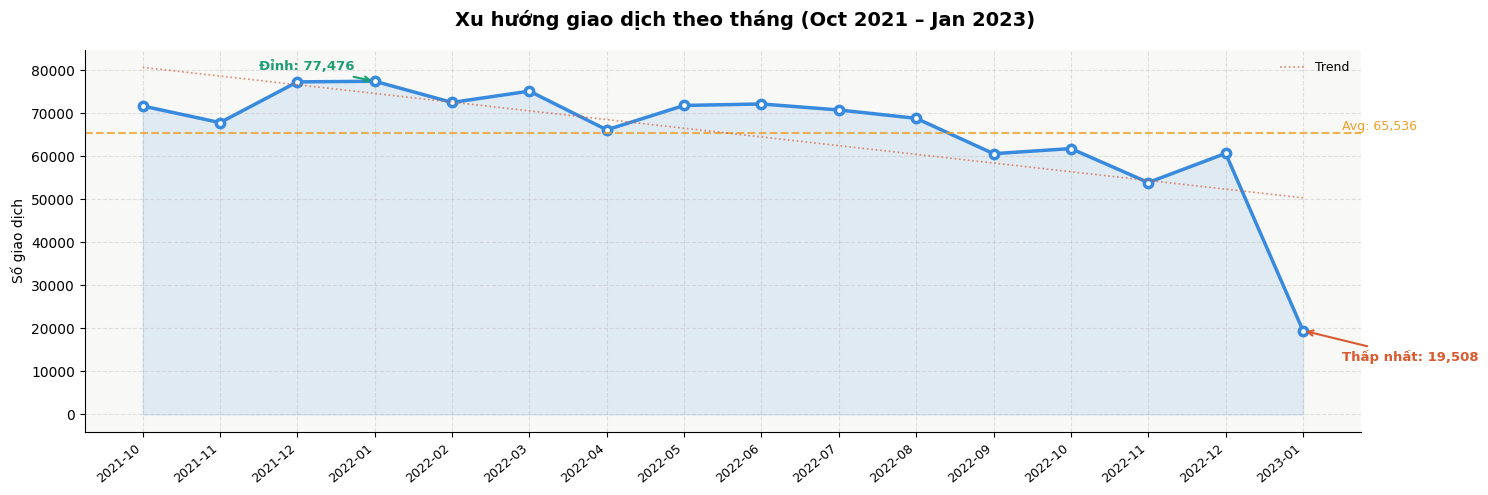

Tăng trưởng tháng đầu → tháng cuối (trừ Jan 2023 chưa đủ tháng):
  2021-10 → 2022-12: -15.4%

Top 3 tháng cao nhất:
year_month
2022-01    77476
2021-12    77328
2022-03    75179
Name: transID, dtype: int64


In [12]:
monthly_t = fact.groupby('year_month')['transID'].count()

fig, ax = plt.subplots(figsize=(15, 5))
fig.suptitle('Xu hướng giao dịch theo tháng (Oct 2021 – Jan 2023)',
             fontsize=14, fontweight='bold')

x = range(len(monthly_t))
ax.fill_between(x, monthly_t.values, alpha=0.12, color=BLUE)
ax.plot(x, monthly_t.values, color=BLUE, linewidth=2.5,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgecolor=BLUE, markeredgewidth=2.5)
ax.set_xticks(x)
ax.set_xticklabels(monthly_t.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Số giao dịch')

# Average line
avg = monthly_t.mean()
ax.axhline(avg, color=AMBER, lw=1.5, ls='--', alpha=0.8)
ax.text(len(monthly_t) - 0.5, avg + 600, f'Avg: {avg:,.0f}', color=AMBER, fontsize=9)

# Annotate peak & trough
peak_i = monthly_t.values.argmax()
low_i  = monthly_t.values.argmin()
ax.annotate(f'Đỉnh: {monthly_t.values[peak_i]:,}',
    xy=(peak_i, monthly_t.values[peak_i]),
    xytext=(peak_i - 1.5, monthly_t.values[peak_i] + 2500),
    color=TEAL, fontsize=9.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5))
ax.annotate(f'Thấp nhất: {monthly_t.values[low_i]:,}',
    xy=(low_i, monthly_t.values[low_i]),
    xytext=(low_i + 0.5, monthly_t.values[low_i] - 7000),
    color=CORAL, fontsize=9.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5))

# Vẽ trend line
z = np.polyfit(list(x), monthly_t.values, 1)
p = np.poly1d(z)
ax.plot(x, p(list(x)), color=CORAL, lw=1.2, ls=':', alpha=0.7, label='Trend')
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

print("Tăng trưởng tháng đầu → tháng cuối (trừ Jan 2023 chưa đủ tháng):")
growth = monthly_t.iloc[-2] / monthly_t.iloc[0] - 1
print(f"  {monthly_t.index[0]} → {monthly_t.index[-2]}: {growth*100:+.1f}%")
print(f"\nTop 3 tháng cao nhất:")
print(monthly_t.sort_values(ascending=False).head(3))

### 🔍 Insights – Xu hướng theo thời gian

- **Peak tháng 1/2022 (77,476 giao dịch)** trùng với dịp Tết Nguyên Đán → nhu cầu ăn uống và tặng quà tăng cao. ZaloPay có thể tận dụng các dịp lễ để chạy campaign.
- **Xu hướng giảm rõ từ Q3/2022** → tín hiệu cảnh báo về việc mất đà tăng trưởng. Cần điều tra nguyên nhân: cạnh tranh, chất lượng merchant, hay user churn?
- **Tháng 9 và 11/2022 xuống thấp nhất** trong kỳ quan sát → đây là giai đoạn "off-peak", phù hợp để triển khai các campaign kích hoạt lại user (re-engagement).
- **Biên độ dao động ổn định (~60K–77K/tháng)** trong suốt 2022 → nền tảng ổn định nhưng thiếu đột phá tăng trưởng.

---

## ✅ Tổng kết – Chân dung User ZaloPay

| Chiều phân tích | Đặc điểm nổi bật |
|---|---|
| **Ai?** | 71.2% đã KYC, phần lớn không khai báo giới tính, median chi tiêu ~312K/user |
| **Ở đâu?** | Hanoi + HCM chiếm 60%, HCM thiên về Delivery, tỉnh thiên về Take Away |
| **Kênh nào?** | Take Away ≈ Delivery (50/48%), STORE walk-in chiếm 50%, APP chỉ 10% |
| **Lý do gì?** | Pizza4P là merchant chủ lực (52.7%), voucher chưa phải động lực chính (9.2%), 50% user chỉ mua 1 lần |
| **Xu hướng?** | Peak Q1/2022, giảm từ Q3/2022, cần chiến lược re-engagement |